# Tarang Full Validation Notebook

Run this notebook on any recorded CSV file. It validates the entire ECG + IMU + DSP pipeline in one shot.

**Usage**: Edit `CSV_PATH` in the next cell, then Run All (Cell → Run All).

In [1]:
# ============ CONFIGURATION ============
# Change this to your CSV file path
CSV_PATH = r'C:\Users\namda\tarang_data\tarang_20260702_131343.csv'

ECG_HZ = 250
IMU_HZ = 100
FRAME_LEN = 256
IMU_PER_FRAME = 32
print(f'Validating: {CSV_PATH}')

Validating: C:\Users\namda\tarang_data\tarang_20260702_131343.csv


In [2]:
# ============ IMPORTS ============
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, sosfiltfilt, iirnotch
from scipy.ndimage import uniform_filter1d
print('Libraries loaded OK')

Libraries loaded OK


In [3]:
# ============ LOAD CSV ============
def load_csv(path):
    rows = []
    header = None
    n_skipped = 0
    with open(path, 'r', encoding='ascii', errors='ignore') as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith('#'):
                continue
            fields = s.split(',')
            if header is None:
                header = fields
                continue
            if len(fields) < 10:
                n_skipped += 1
                continue
            try:
                rows.append([float(x) for x in fields[:10]])
            except ValueError:
                n_skipped += 1
    arr = np.array(rows, dtype=np.float64)
    return {
        't_us': arr[:,0], 'ecg_idx': arr[:,1], 'imu_idx': arr[:,2],
        'ecg_raw': arr[:,3], 'ecg_mv': arr[:,4],
        'ax': arr[:,5], 'ay': arr[:,6], 'az': arr[:,7],
        'imu_mag': arr[:,8], 'lo+': arr[:,9],
    }, header, n_skipped

data, header, n_skipped = load_csv(CSV_PATH)
t_us = data['t_us']
ecg_mv = data['ecg_mv']
ecg_raw = data['ecg_raw']
ax, ay, az = data['ax'], data['ay'], data['az']
imu_mag_csv = data['imu_mag']
duration_s = (t_us[-1] - t_us[0]) / 1e6
print(f'Loaded {len(t_us)} rows, {duration_s:.2f} s, {n_skipped} malformed lines skipped')

Loaded 30631 rows, 122.52 s, 1 malformed lines skipped


ECG mean rate: 250.000 Hz (target 250)
ECG jitter p2p: 0.000 ms
IMU mean rate: 100.000 Hz (target 100)
IMU drops: 0


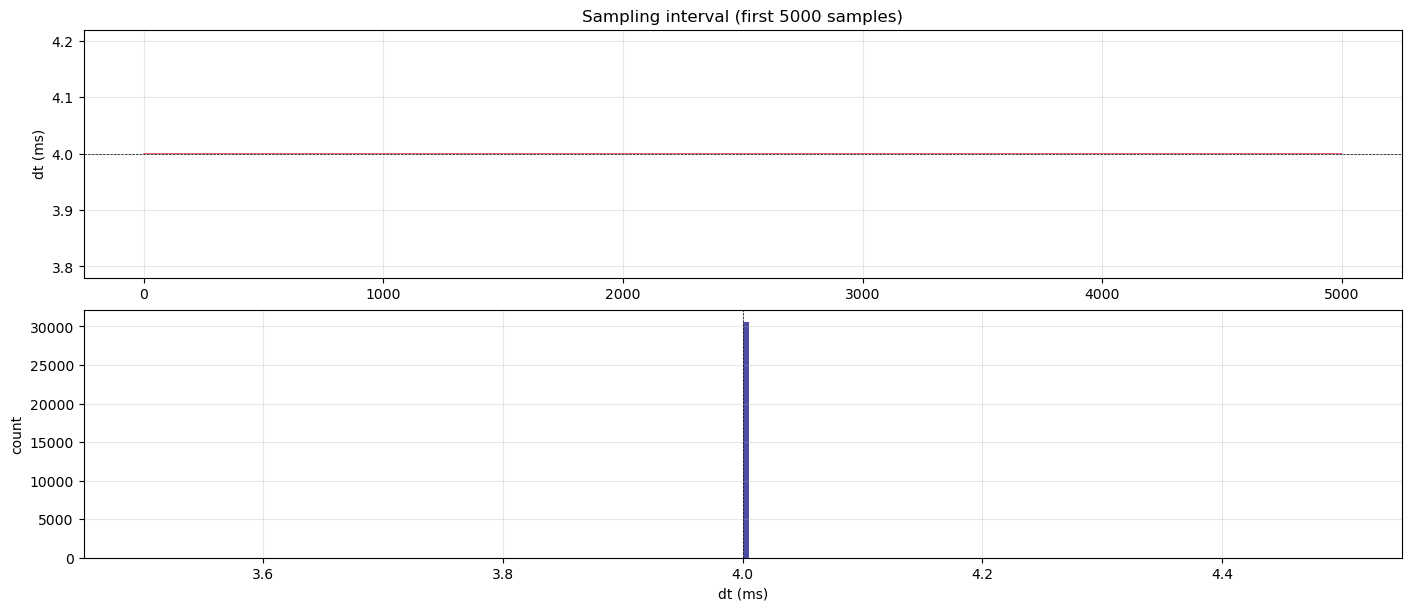

In [4]:
# ============ SAMPLING RATE CHECK ============
dt_us = np.diff(t_us)
dt_ms = dt_us / 1000.0
rate_hz = 1e6 / dt_us
ecg_mean = float(np.mean(rate_hz))
ecg_p2p = float(np.max(dt_ms) - np.min(dt_ms))

unique_imu = np.unique(data['imu_idx'])
imu_rate = (len(unique_imu) - 1) / duration_s if duration_s > 0 else 0

imu_seq = []
last = None
for v in data['imu_idx']:
    if v != last:
        imu_seq.append(v); last = v
imu_drops = int(np.sum(np.diff(imu_seq) != 1))

print(f'ECG mean rate: {ecg_mean:.3f} Hz (target {ECG_HZ})')
print(f'ECG jitter p2p: {ecg_p2p:.3f} ms')
print(f'IMU mean rate: {imu_rate:.3f} Hz (target {IMU_HZ})')
print(f'IMU drops: {imu_drops}')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), constrained_layout=True)
ax1.plot(dt_ms[:5000], lw=0.5, color='crimson')
ax1.axhline(4.0, color='k', ls='--', lw=0.5)
ax1.set_title('Sampling interval (first 5000 samples)')
ax1.set_ylabel('dt (ms)'); ax1.grid(alpha=0.3)
ax2.hist(dt_ms, bins=200, color='navy', alpha=0.7)
ax2.axvline(4.0, color='k', ls='--', lw=0.5)
ax2.set_xlabel('dt (ms)'); ax2.set_ylabel('count'); ax2.grid(alpha=0.3)
plt.show()

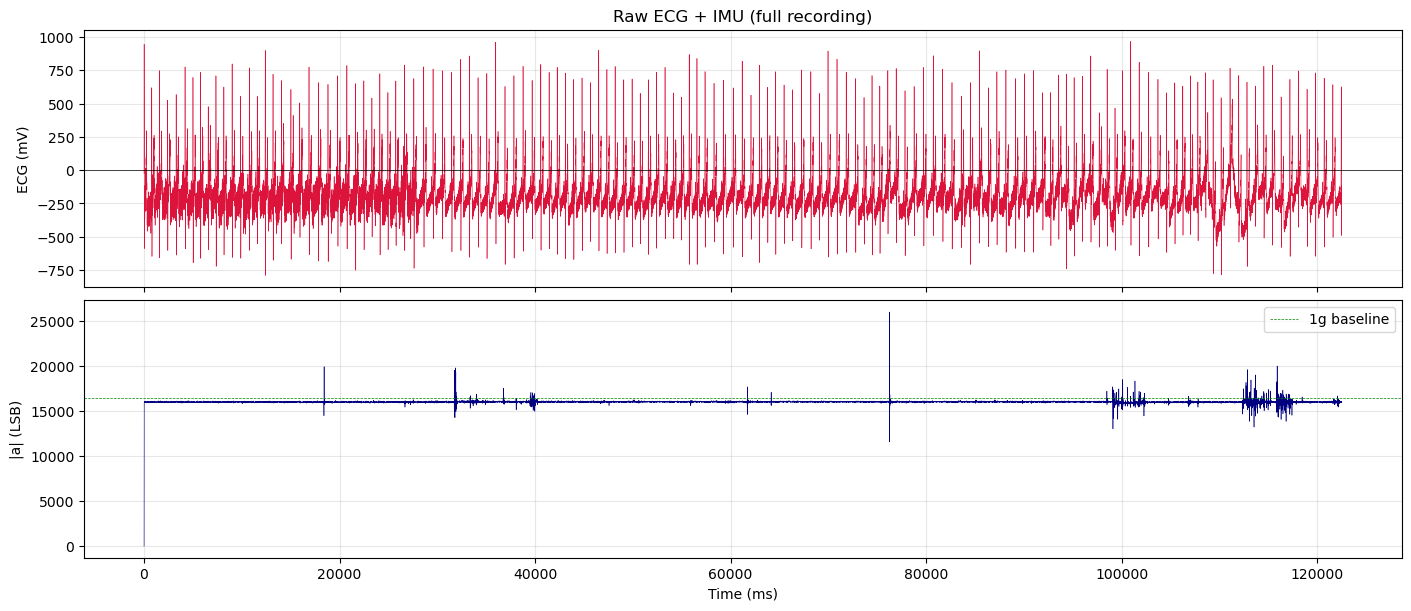

IMU all zeros? False


In [5]:
# ============ ECG + IMU RAW PLOT ============
imu_mag = np.sqrt(ax**2 + ay**2 + az**2)
imu_all_zero = np.all(imu_mag == 0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True, constrained_layout=True)
t_ms = (t_us - t_us[0]) / 1000.0
ax1.plot(t_ms, ecg_mv, lw=0.4, color='crimson')
ax1.set_ylabel('ECG (mV)'); ax1.set_title('Raw ECG + IMU (full recording)')
ax1.grid(alpha=0.3); ax1.axhline(0, color='k', lw=0.5)
ax2.plot(t_ms, imu_mag, lw=0.4, color='navy')
ax2.axhline(16384, color='g', ls='--', lw=0.5, label='1g baseline')
ax2.set_ylabel('|a| (LSB)'); ax2.set_xlabel('Time (ms)')
ax2.grid(alpha=0.3); ax2.legend(loc='upper right')
plt.show()
print(f'IMU all zeros? {imu_all_zero}')

In [6]:
# ============ DSP PIPELINE ============
def dc_remove(x): return x - np.mean(x)
def baseline_wander_remove(x, fs=250, cutoff=0.5):
    b, a = butter(1, cutoff/(fs/2), btype='high')
    return filtfilt(b, a, x)
def bandpass(x, fs=250, low=0.5, high=40.0):
    sos = butter(2, [low/(fs/2), high/(fs/2)], btype='band', output='sos')
    return sosfiltfilt(sos, x)
def notch_50hz(x, fs=250, q=30.0):
    b, a = iirnotch(50.0, q, fs=fs)
    return filtfilt(b, a, x)

ecg_dc = dc_remove(ecg_mv)
ecg_baseline = baseline_wander_remove(ecg_dc, fs=ECG_HZ)
ecg_bp = bandpass(ecg_baseline, fs=ECG_HZ)
ecg_notch = notch_50hz(ecg_bp, fs=ECG_HZ)
print('DSP chain: DC -> baseline -> bandpass -> notch OK')

DSP chain: DC -> baseline -> bandpass -> notch OK


In [7]:
# ============ NLMS ============
def nlms_filter(primary, reference, num_taps=32, mu=0.01, eps=1.0, adapt_mask=None):
    primary = np.asarray(primary, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    if len(reference) != len(primary):
        x_old = np.linspace(0,1,len(reference)); x_new = np.linspace(0,1,len(primary))
        reference = np.interp(x_new, x_old, reference)
    N = len(primary); L = int(num_taps)
    if adapt_mask is None: adapt_mask = np.ones(N, dtype=bool)
    else: adapt_mask = np.asarray(adapt_mask, dtype=bool)
    w = np.zeros(L); delay = np.zeros(L); d_idx = 0
    y_hat = np.zeros(N); cleaned = np.zeros(N)
    for n in range(N):
        delay[d_idx] = reference[n]
        x = np.array([delay[(d_idx-k)%L] for k in range(L)])
        y = float(np.dot(w, x)); y_hat[n] = y
        e = primary[n] - y; cleaned[n] = e
        if adapt_mask[n]:
            denom = float(np.dot(x,x)) + eps
            if denom > 0: w += (mu*e/denom)*x
        d_idx = (d_idx+1) % L
    return {'cleaned': cleaned, 'y_hat': y_hat, 'weights': w}

def motion_gate(imu_mag, baseline=16384.0, threshold=300.0):
    return np.abs(imu_mag - baseline) > threshold

if imu_all_zero:
    print('WARNING: IMU all zeros — skipping NLMS, using bandpass+notch as cleaned')
    ecg_clean = ecg_notch.copy()
    adapt_mask = np.zeros(len(ecg_mv), dtype=bool)
    nlms_w_norm = 0.0
else:
    imu_env = uniform_filter1d(imu_mag - 16384.0, size=25)
    adapt_mask = motion_gate(imu_mag)
    motion_pct = 100.0 * np.sum(adapt_mask) / len(adapt_mask)
    print(f'Motion active: {motion_pct:.1f}% of samples')
    r = nlms_filter(ecg_notch, imu_env, num_taps=32, mu=0.01, eps=1.0, adapt_mask=adapt_mask)
    ecg_clean = r['cleaned']
    nlms_w_norm = float(np.linalg.norm(r['weights']))
    print(f'NLMS |w|_2: {nlms_w_norm:.4f}')
    print(f'NaN/Inf: {np.any(np.isnan(ecg_clean)) or np.any(np.isinf(ecg_clean))}')

Motion active: 96.4% of samples
NLMS |w|_2: 0.0536
NaN/Inf: False


In [8]:
# ============ PAN-TOMPKINS ============
def pan_tompkins(ecg, fs=250, refractory_ms=250, mwi_ms=150):
    ecg = np.asarray(ecg, dtype=np.float64)
    n = len(ecg)
    if n < fs:
        return {'r_peaks': np.array([]), 'heart_rate': 0.0, 'rr_intervals': np.array([]),
                'r_times_s': np.array([])}
    ny = fs/2.0
    b, a = butter(2, [5.0/ny, 15.0/ny], btype='band')
    bp = filtfilt(b, a, ecg)
    d = np.zeros_like(bp)
    for i in range(2, n-2):
        d[i] = (-bp[i-2] - 2*bp[i-1] + 2*bp[i+1] + bp[i+2]) / 8.0
    sq = d**2
    mwi_w = max(1, int(fs*mwi_ms/1000.0))
    k = np.ones(mwi_w)/mwi_w
    sig = np.convolve(sq, k, mode='full')[:n]
    refractory = int(fs*refractory_ms/1000.0)
    sig_max = float(np.max(sig))
    signal_level = 0.5*sig_max
    threshold = signal_level
    r_peaks = []
    last_peak = -refractory
    for i in range(1, n-1):
        if sig[i] > sig[i-1] and sig[i] >= sig[i+1] and sig[i] > threshold:
            if i - last_peak >= refractory:
                w = max(2, int(fs*0.025))
                lo = max(0, i-w); hi = min(n, i+w+1)
                local_idx = lo + int(np.argmax(np.abs(ecg[lo:hi])))
                r_peaks.append(local_idx)
                last_peak = local_idx
                signal_level = 0.25*sig[i] + 0.75*signal_level
                threshold = signal_level
    r_peaks = np.array(sorted(set(r_peaks)), dtype=np.int64)
    r_times_s = r_peaks / float(fs)
    if len(r_peaks) >= 2:
        rr = np.diff(r_peaks) / float(fs)
        hr = 60.0/float(np.median(rr)) if np.median(rr) > 0 else 0.0
    else:
        rr = np.array([]); hr = 0.0
    return {'r_peaks': r_peaks, 'heart_rate': hr, 'rr_intervals': rr, 'r_times_s': r_times_s}

pt_raw = pan_tompkins(ecg_notch, fs=ECG_HZ)
pt_clean = pan_tompkins(ecg_clean, fs=ECG_HZ)
print(f'Raw ECG: {len(pt_raw["r_peaks"])} R-peaks, HR={pt_raw["heart_rate"]:.1f} bpm')
print(f'Cleaned: {len(pt_clean["r_peaks"])} R-peaks, HR={pt_clean["heart_rate"]:.1f} bpm')

Raw ECG: 26 R-peaks, HR=63.0 bpm
Cleaned: 27 R-peaks, HR=63.3 bpm


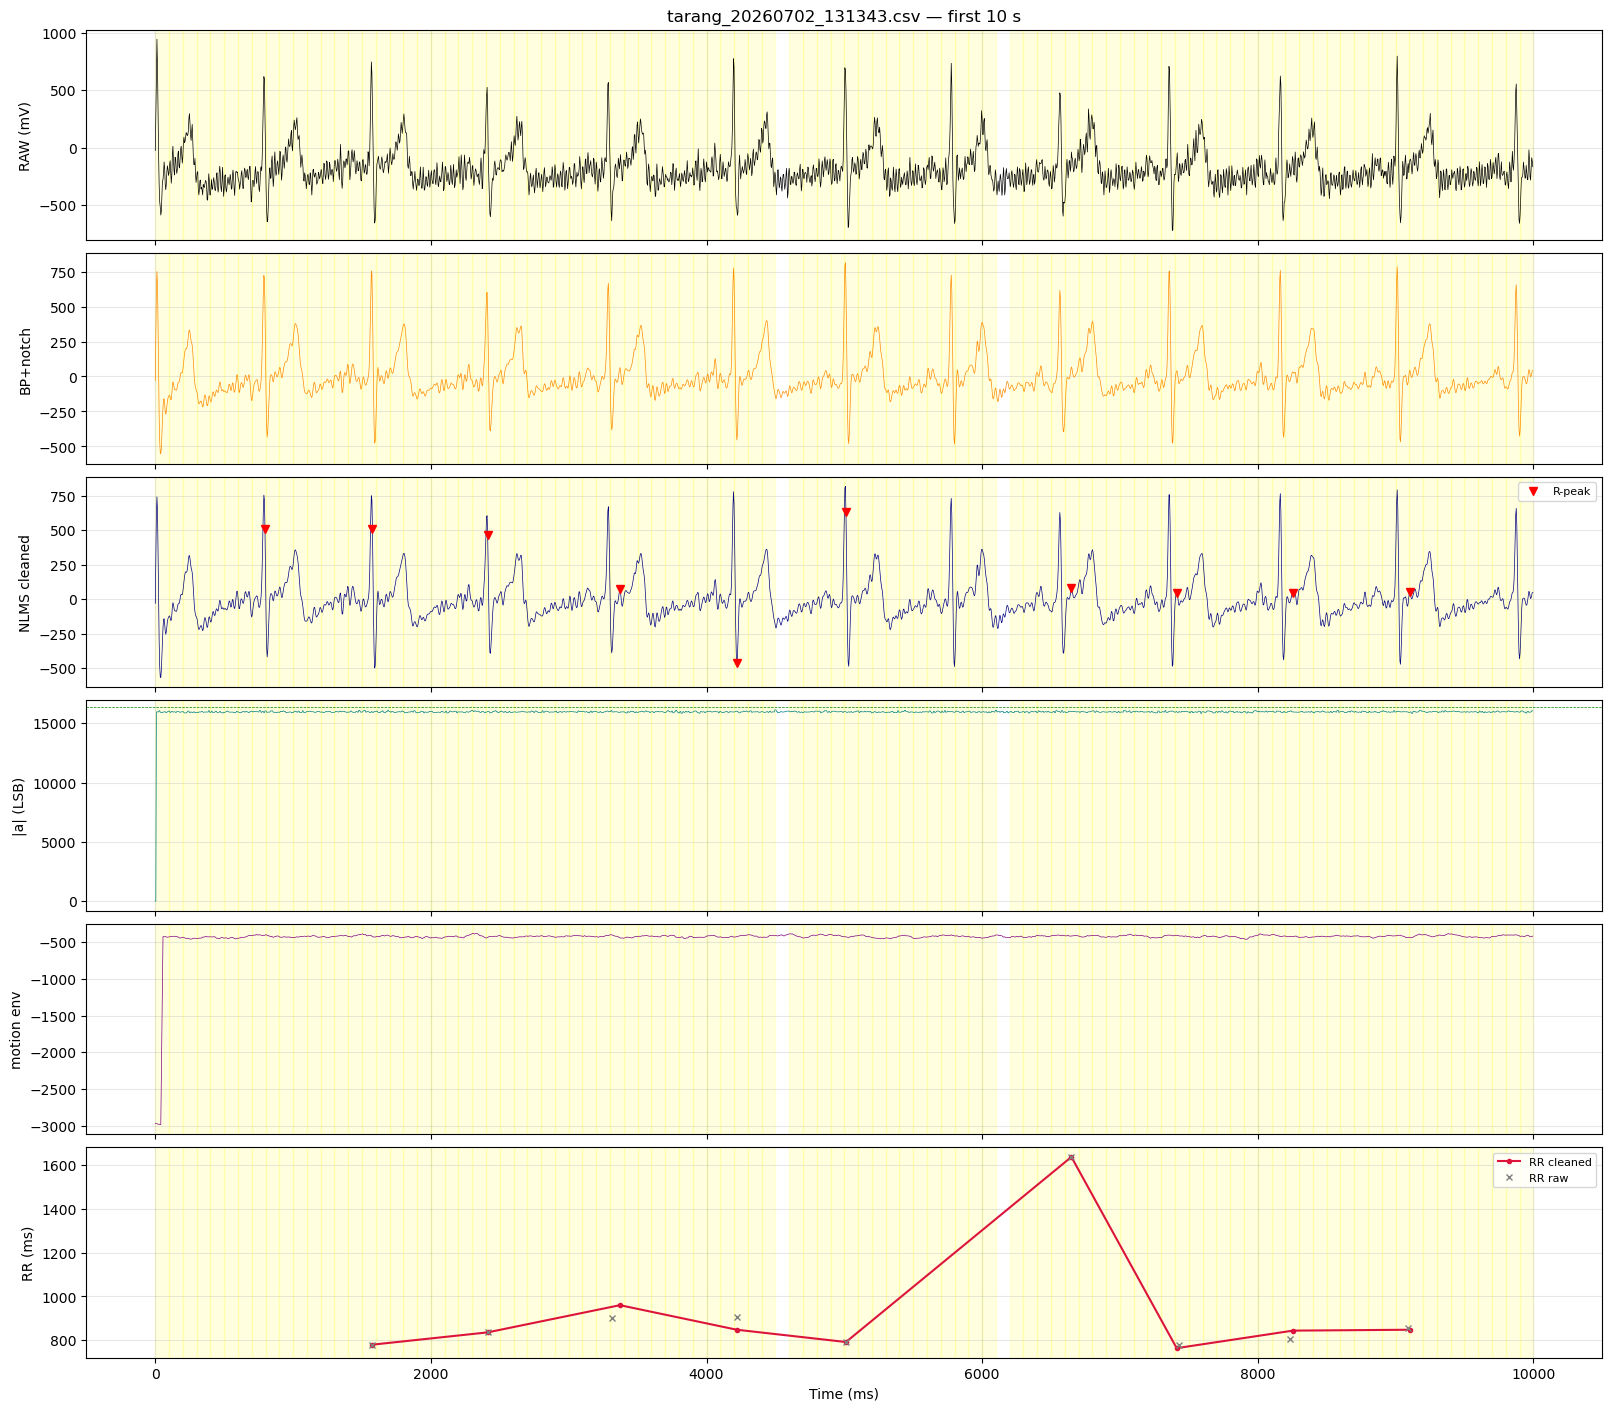

In [9]:
# ============ FULL COMPARISON PLOT ============
N_show = min(len(ecg_mv), 10*ECG_HZ)
t_show = (t_us[:N_show] - t_us[0]) / 1000.0

fig, axs = plt.subplots(6, 1, figsize=(16, 14), sharex=True, constrained_layout=True)
axs[0].plot(t_show, ecg_mv[:N_show], lw=0.5, color='k')
axs[0].set_ylabel('RAW (mV)'); axs[0].grid(alpha=0.3)
axs[0].set_title(f'{os.path.basename(CSV_PATH)} — first 10 s')

axs[1].plot(t_show, ecg_notch[:N_show], lw=0.5, color='darkorange')
axs[1].set_ylabel('BP+notch'); axs[1].grid(alpha=0.3)

axs[2].plot(t_show, ecg_clean[:N_show], lw=0.5, color='navy')
rp = pt_clean['r_peaks']; rp = rp[(rp>=0) & (rp<N_show)]
if len(rp) > 0:
    axs[2].plot(t_show[rp], ecg_clean[rp], 'rv', ms=6, label='R-peak')
    axs[2].legend(loc='upper right', fontsize=8)
axs[2].set_ylabel('NLMS cleaned'); axs[2].grid(alpha=0.3)

axs[3].plot(t_show, imu_mag[:N_show], lw=0.5, color='teal')
axs[3].axhline(16384, color='g', ls='--', lw=0.5)
axs[3].set_ylabel('|a| (LSB)'); axs[3].grid(alpha=0.3)

if not imu_all_zero:
    imu_env_show = uniform_filter1d(imu_mag - 16384.0, size=25)
    axs[4].plot(t_show, imu_env_show[:N_show], lw=0.5, color='purple')
axs[4].set_ylabel('motion env'); axs[4].grid(alpha=0.3)

if len(pt_clean['rr_intervals']) > 0:
    rr_t = pt_clean['r_times_s'][1:] * 1000
    mask = rr_t <= t_show[-1]
    axs[5].plot(rr_t[mask], pt_clean['rr_intervals'][mask]*1000, 'o-', ms=3, color='crimson', label='RR cleaned')
    if len(pt_raw['rr_intervals']) > 0:
        rr_t_raw = pt_raw['r_times_s'][1:] * 1000
        mask_r = rr_t_raw <= t_show[-1]
        axs[5].plot(rr_t_raw[mask_r], pt_raw['rr_intervals'][mask_r]*1000, 'x', ms=4, color='gray', label='RR raw')
    axs[5].legend(loc='upper right', fontsize=8)
axs[5].set_ylabel('RR (ms)'); axs[5].grid(alpha=0.3)
axs[5].set_xlabel('Time (ms)')

if not imu_all_zero:
    for i in range(0, N_show, 25):
        if adapt_mask[i]:
            for ax in axs:
                ax.axvspan(t_show[i], t_show[min(i+25, N_show-1)], color='yellow', alpha=0.12)
plt.show()

In [10]:
# ============ FINAL PASS/FAIL REPORT ============
checks = []

# Sampling
checks.append(('ECG rate 249.5-250.5 Hz', 249.5 <= ecg_mean <= 250.5, f'{ecg_mean:.3f} Hz'))
checks.append(('ECG jitter < 10 ms', ecg_p2p < 10.0, f'{ecg_p2p:.3f} ms'))
checks.append(('IMU rate 99.5-100.5 Hz', 99.5 <= imu_rate <= 100.5, f'{imu_rate:.3f} Hz'))
checks.append(('IMU drops = 0', imu_drops == 0, f'{imu_drops}'))

# ECG quality
sat_low = np.sum(ecg_raw < 200) / len(ecg_raw)
sat_high = np.sum(ecg_raw > 3900) / len(ecg_raw)
checks.append(('ECG not saturated', sat_low < 0.1 and sat_high < 0.1, f'low={sat_low*100:.1f}% high={sat_high*100:.1f}%'))
electrodes = np.mean(data['lo+'] < 0.5) > 0.5
checks.append(('Electrodes attached', electrodes, f'{np.mean(data["lo+"]<0.5)*100:.1f}%'))

# IMU quality
checks.append(('IMU data present', not imu_all_zero, 'all zeros' if imu_all_zero else 'OK'))

# Pan-Tompkins
n_peaks = len(pt_raw['r_peaks'])
checks.append(('R-peaks detected (>30)', n_peaks > 30, f'{n_peaks} peaks'))
hr = pt_raw['heart_rate']
checks.append(('HR plausible (40-150)', 40 <= hr <= 150, f'{hr:.1f} bpm'))

# NLMS
rms_raw = float(np.sqrt(np.mean(ecg_mv**2)))
rms_clean = float(np.sqrt(np.mean(ecg_clean**2)))
checks.append(('NLMS reduces RMS', rms_clean <= rms_raw * 1.05, f'raw={rms_raw:.2f} clean={rms_clean:.2f}'))
checks.append(('NLMS stable (no NaN)', not np.any(np.isnan(ecg_clean)), ''))
checks.append(('NLMS weights bounded', nlms_w_norm < 1e6, f'|w|={nlms_w_norm:.4f}'))

print('='*70)
print('FINAL PASS/FAIL SUMMARY')
print('='*70)
for name, passed, detail in checks:
    status = 'PASS' if passed else 'FAIL'
    print(f'  [{status}] {name}' + (f' — {detail}' if detail else ''))
n_pass = sum(1 for _, p, _ in checks if p)
print('='*70)
print(f'Overall: {n_pass}/{len(checks)} checks passed')
print('='*70)

FINAL PASS/FAIL SUMMARY
  [PASS] ECG rate 249.5-250.5 Hz — 250.000 Hz
  [PASS] ECG jitter < 10 ms — 0.000 ms
  [PASS] IMU rate 99.5-100.5 Hz — 100.000 Hz
  [PASS] IMU drops = 0 — 0
  [PASS] ECG not saturated — low=0.0% high=0.0%
  [PASS] Electrodes attached — 100.0%
  [PASS] IMU data present — OK
  [FAIL] R-peaks detected (>30) — 26 peaks
  [PASS] HR plausible (40-150) — 63.0 bpm
  [PASS] NLMS reduces RMS — raw=243.69 clean=151.98
  [PASS] NLMS stable (no NaN)
  [PASS] NLMS weights bounded — |w|=0.0536
Overall: 11/12 checks passed
